In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv("C:/pramod/New start of career/lectures/Assignment 4/part_a/q2_customers.csv")


In [ ]:
df.head()
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


## scale all features

In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['age', 'annual_spend', 'visits_per_month', 'basket_size','days_since_last_visit','num_categories_purchased']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



2. Choosing K — Elbow Method

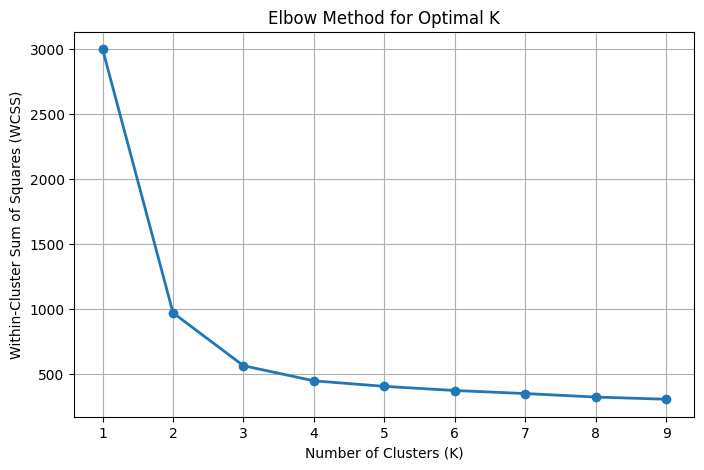

In [ ]:
wcss = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()


3. K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [ ]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=features)
centroid_df.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
print(centroid_df)


                 age  annual_spend  visits_per_month  basket_size  \
Cluster 0  24.676471  14847.370588         14.341176   558.970588   
Cluster 1  56.769697  89413.333333          2.527273  5530.545455   
Cluster 2  40.387879  43340.733333          8.193939  2021.684848   

           days_since_last_visit  num_categories_purchased  
Cluster 0               9.076471                  2.111765  
Cluster 1             105.357576                  7.515152  
Cluster 2              35.187879                  4.424242  


Dimensionality Reduction with PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [ ]:
print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")


PC1 variance explained: 83.56%
PC2 variance explained: 5.57%
Total variance explained: 89.13%


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)
print(loadings)


                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


5. Cluster Visualisation 

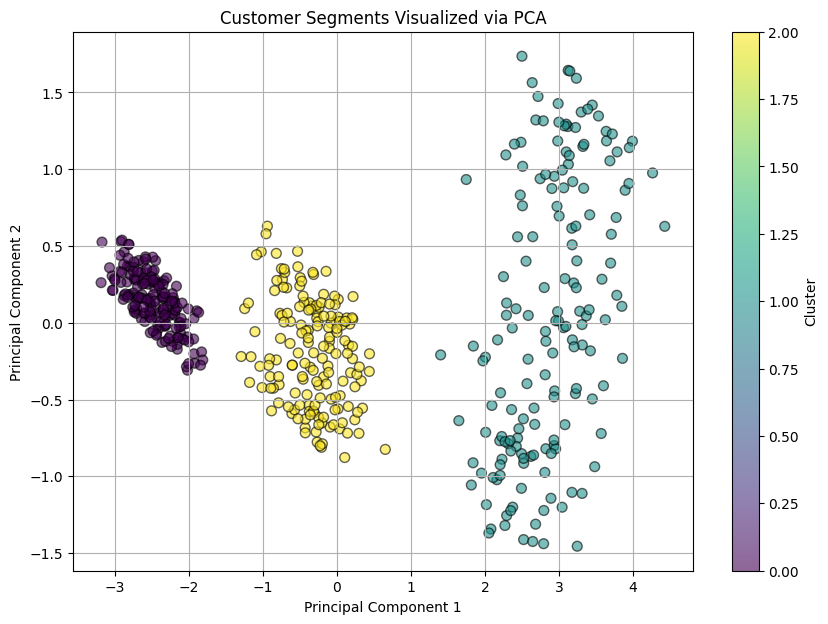

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='viridis',
                      alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments Visualized via PCA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()
